In [ ]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT   = Path().resolve().parent
IMAGES_DIR  = REPO_ROOT / "extracted_images_4.8k_V2"
image_paths = sorted(list(IMAGES_DIR.glob("*.jpg")))

# ── HSV green thresholds ──────────────────────────────────────────────────────
# Tightened from [40,40,40] to reject low-saturation foliage and shadows
# while keeping the bright painted road line. Verify on foliage frames in step 4.
LOWER_GREEN = np.array([45,  60,  60])
UPPER_GREEN = np.array([85, 255, 255])

MIN_CONTOUR_AREA = 100
DEAD_BAND        = 0.10

# ── Change this one value to inspect a different frame everywhere ──
FRAME_INDEX = 741
# ──────────────────────────────────────────────────────────────────

# ── Trapezoid ROI (measured from actual frames, H=720, W=1280) ────────
TRAP_BOT_Y   = 0.85
TRAP_TOP_Y   = 0.45
TRAP_BOT_X_L = 0.328
TRAP_BOT_X_R = 0.789
TRAP_TOP_X_L = 0.403
TRAP_TOP_X_R = 0.697
# ─────────────────────────────────────────────────────────────────────

# ── Car center in image (empirically measured from straight frames) ───
CAR_CENTER_X    = 693   # px — line at this x means car is perfectly centered
CAR_CENTER_FRAC = CAR_CENTER_X / 1280  # 0.541
# ─────────────────────────────────────────────────────────────────────

img_bgr = cv2.imread(str(image_paths[FRAME_INDEX]))
H, W    = img_bgr.shape[:2]

trap_pts = np.array([
    [int(TRAP_TOP_X_L * W), int(TRAP_TOP_Y * H)],
    [int(TRAP_TOP_X_R * W), int(TRAP_TOP_Y * H)],
    [int(TRAP_BOT_X_R * W), int(TRAP_BOT_Y * H)],
    [int(TRAP_BOT_X_L * W), int(TRAP_BOT_Y * H)],
], dtype=np.int32)

print(f"Image: {image_paths[FRAME_INDEX].name}  shape={img_bgr.shape}  ({len(image_paths)} total frames)")
print(f"Trapezoid (px): TL={trap_pts[0]}  TR={trap_pts[1]}  BR={trap_pts[2]}  BL={trap_pts[3]}")
print(f"Car center: {CAR_CENTER_X}px ({CAR_CENTER_FRAC:.3f})  image center: {W//2}px  shift: {CAR_CENTER_X - W//2:+d}px")
print(f"HSV thresholds: lower={LOWER_GREEN.tolist()}  upper={UPPER_GREEN.tolist()}")


Image: frame_000742.jpg  shape=(720, 1280, 3)  (4802 total frames)
Trapezoid (px): TL=[515 324]  TR=[892 324]  BR=[1009  612]  BL=[419 612]
Car center: 693px (0.541)  image center: 640px  shift: +53px
HSV thresholds: lower=[45, 60, 60]  upper=[85, 255, 255]


## Label validation — `compute_label()`

Uses the same trapezoid + band sampling + geometric formula as `01_extract_dataset.ipynb`.

Produces the **6-feature vector** `[off_bot, off_mid, off_top, has_bot, has_mid, has_top]`
and the geometric steering label for each frame.

- Change `FRAME_INDEX` in the setup cell above and re-run all cells to inspect any frame.
- **Single frame** — annotated label visualization with bot/mid/top dots and steering bar.
- **Multi-frame grid** — 8 consecutive frames at once.
- **Individual large frames** — 6 consecutive frames, one per row, full size.


## Step-by-step mask pipeline

Shows each processing stage for the current `FRAME_INDEX`.
Useful for tuning HSV thresholds — if the line disappears between step 3 and 4, the morphological open kernel is too large.


Frame 741  |  HSV thresholds: lower=[45, 60, 60]  upper=[85, 255, 255]
  Raw mask pixels    : 197
  After MORPH_CLOSE  : 211
  After MORPH_OPEN   : 80  ← this is what compute_label() uses


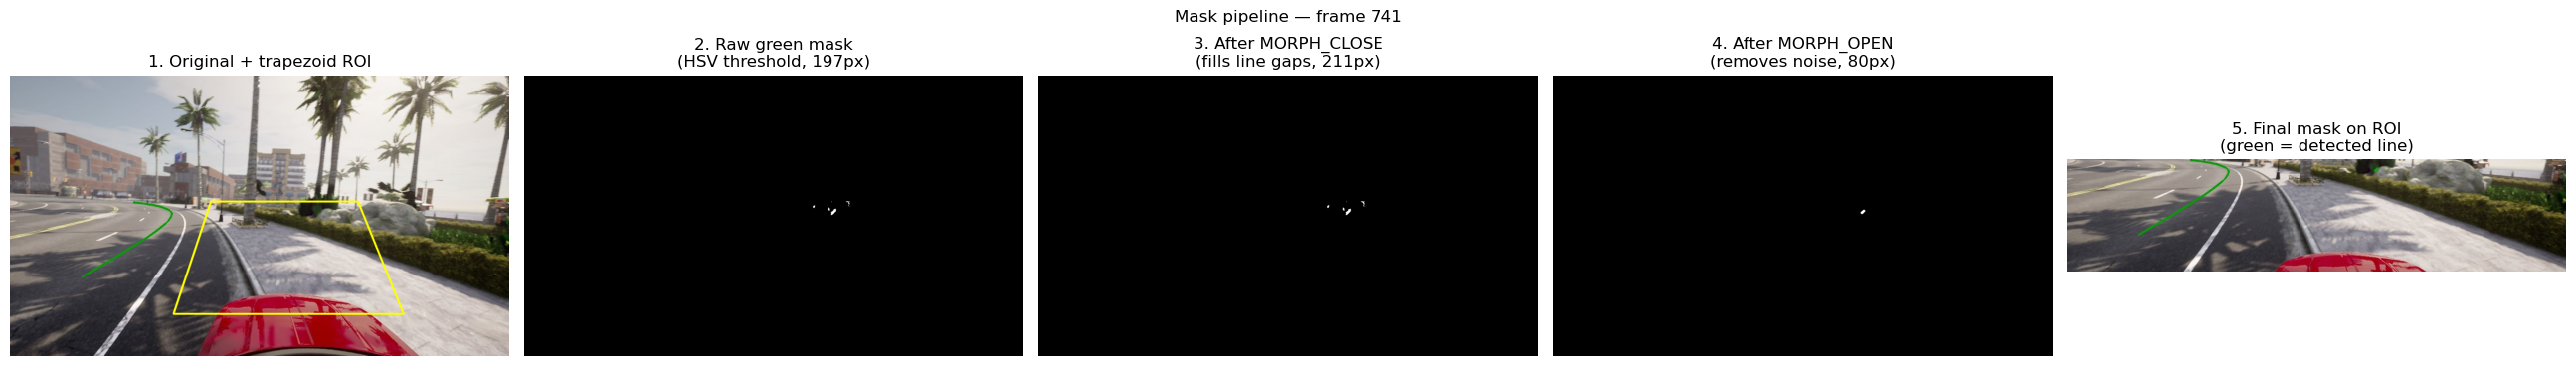

In [2]:
# ── Step-by-step mask pipeline for FRAME_INDEX ───────────────────────────────
trap_mask = np.zeros((H, W), dtype=np.uint8)
cv2.fillPoly(trap_mask, [trap_pts], 255)

y_top = trap_pts[:, 1].min()
y_bot = trap_pts[:, 1].max()

# Step 1: original with trapezoid outline
p1 = img_bgr.copy()
cv2.polylines(p1, [trap_pts], isClosed=True, color=(0, 255, 255), thickness=3)

# Step 2: HSV → raw green mask (before morphology)
hsv_full = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
p2_raw   = cv2.inRange(hsv_full, LOWER_GREEN, UPPER_GREEN)
p2       = cv2.bitwise_and(p2_raw, trap_mask)   # clipped to trapezoid

# Step 3: MORPH_CLOSE (fills gaps in the line)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
p3     = cv2.morphologyEx(p2, cv2.MORPH_CLOSE, kernel)

# Step 4: MORPH_OPEN (removes small noise blobs)
p4 = cv2.morphologyEx(p3, cv2.MORPH_OPEN, kernel)

# Step 5: mask overlaid on ROI crop
roi_crop = img_bgr[y_top:y_bot, :].copy()
overlay  = roi_crop.copy()
overlay[p4[y_top:y_bot, :] > 0] = [0, 220, 0]
p5 = cv2.addWeighted(overlay, 0.6, roi_crop, 0.4, 0)

n_raw   = (p2 > 0).sum()
n_close = (p3 > 0).sum()
n_open  = (p4 > 0).sum()
print(f"Frame {FRAME_INDEX}  |  HSV thresholds: lower={LOWER_GREEN.tolist()}  upper={UPPER_GREEN.tolist()}")
print(f"  Raw mask pixels    : {n_raw}")
print(f"  After MORPH_CLOSE  : {n_close}")
print(f"  After MORPH_OPEN   : {n_open}  ← this is what compute_label() uses")
if n_raw > 0 and n_open == 0:
    print("  ⚠ MORPH_OPEN erased all pixels — kernel too large or line too thin")
elif n_open < 20:
    print("  ⚠ Very few pixels after open — likely to be skipped (threshold: 20px)")

fig, axes = plt.subplots(1, 5, figsize=(26, 4))
fig.suptitle(f"Mask pipeline — frame {FRAME_INDEX}", fontsize=12)

axes[0].imshow(cv2.cvtColor(p1, cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Original + trapezoid ROI")

axes[1].imshow(p2, cmap="gray")
axes[1].set_title(f"2. Raw green mask\n(HSV threshold, {n_raw}px)")

axes[2].imshow(p3, cmap="gray")
axes[2].set_title(f"3. After MORPH_CLOSE\n(fills line gaps, {n_close}px)")

axes[3].imshow(p4, cmap="gray")
axes[3].set_title(f"4. After MORPH_OPEN\n(removes noise, {n_open}px)")

axes[4].imshow(cv2.cvtColor(p5, cv2.COLOR_BGR2RGB))
axes[4].set_title("5. Final mask on ROI\n(green = detected line)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8-frame mask comparison

Shows the final mask (step 4) overlaid on the ROI for 8 consecutive frames starting at `FRAME_INDEX`.
Quickly reveals frames where the line is lost or foliage bleeds through.


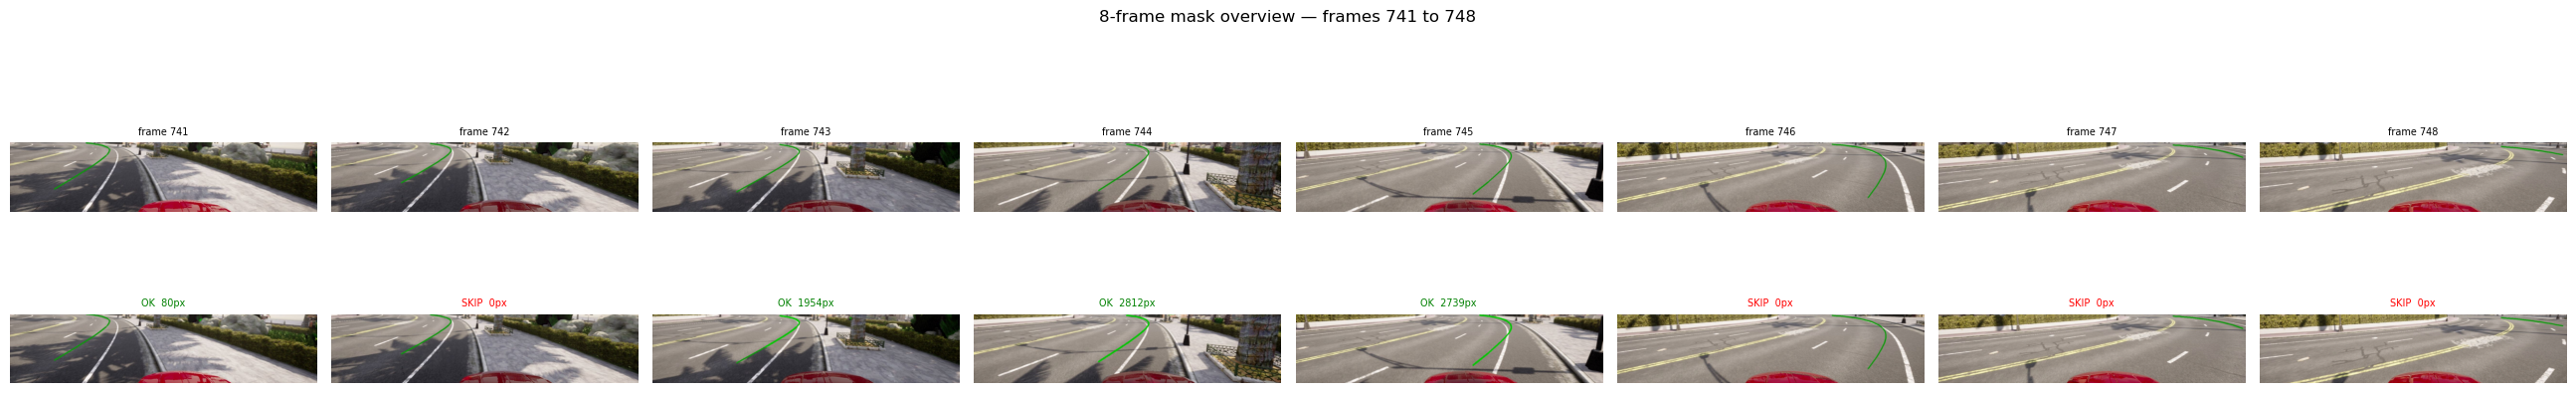

In [3]:
# ── 8-frame mask comparison ───────────────────────────────────────────────────
N_MASK = 8
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

fig, axes = plt.subplots(2, N_MASK, figsize=(26, 5))
fig.suptitle(f"8-frame mask overview — frames {FRAME_INDEX} to {FRAME_INDEX + N_MASK - 1}", fontsize=12)

for col, offset in enumerate(range(N_MASK)):
    idx = FRAME_INDEX + offset
    if idx >= len(image_paths):
        axes[0, col].axis("off")
        axes[1, col].axis("off")
        continue

    fr       = cv2.imread(str(image_paths[idx]))
    yt, yb   = trap_pts[:, 1].min(), trap_pts[:, 1].max()
    roi_fr   = fr[yt:yb, :]

    hsv_fr   = cv2.cvtColor(fr, cv2.COLOR_BGR2HSV)
    raw_fr   = cv2.inRange(hsv_fr, LOWER_GREEN, UPPER_GREEN)
    raw_fr   = cv2.bitwise_and(raw_fr, trap_mask)
    closed   = cv2.morphologyEx(raw_fr, cv2.MORPH_CLOSE, kernel)
    final_fr = cv2.morphologyEx(closed, cv2.MORPH_OPEN,  kernel)

    n_px = (final_fr > 0).sum()
    status = "OK" if n_px >= 20 else "SKIP"
    color  = "green" if n_px >= 20 else "red"

    # Top row: original ROI
    axes[0, col].imshow(cv2.cvtColor(roi_fr, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"frame {idx}", fontsize=7)
    axes[0, col].axis("off")

    # Bottom row: final mask overlaid
    ov = roi_fr.copy()
    ov[final_fr[yt:yb, :] > 0] = [0, 220, 0]
    blend = cv2.addWeighted(ov, 0.6, roi_fr, 0.4, 0)
    axes[1, col].imshow(cv2.cvtColor(blend, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f"{status}  {n_px}px", fontsize=7, color=color)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
def compute_label(img_bgr, trap_pts, lower_green, upper_green, car_center_x):
    """
    Compute the geometric training label for one frame.
    Returns (label_steer, info_dict, annotated_vis)
    """
    H, W = img_bgr.shape[:2]
    half = W / 2.0  # used to normalise pixel offsets to [-1, 1]

    # Build trapezoid mask — pixels outside the ROI are ignored
    tm = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(tm, [trap_pts], 255)

    # HSV colour filtering → close gaps → remove noise → clip to ROI
    hsv   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    green = cv2.inRange(hsv, lower_green, upper_green)
    k     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    green = cv2.morphologyEx(green, cv2.MORPH_CLOSE, k)  # fills small holes in the line
    green = cv2.morphologyEx(green, cv2.MORPH_OPEN,  k)  # removes isolated noise blobs
    green = cv2.bitwise_and(green, tm)

    # Crop to the vertical extent of the trapezoid for faster row-wise lookups
    y_top_t = trap_pts[:, 1].min()
    y_bot_t = trap_pts[:, 1].max()
    gmask   = green[y_top_t:y_bot_t, :]
    rr, cc  = gmask.shape[:2]  # rows / cols of the cropped mask

    ys, xs = np.where(gmask > 0)
    if len(ys) < 20:  # too few pixels — frame likely has no visible line
        return None, {}, img_bgr.copy()

    def band_cx_adaptive(search_start, search_end, slice_half=0.07):
        """
        Scan row-by-row (direction set by search_start vs search_end) and return
        the centroid x of the first horizontal band that contains ≥5 green pixels.
        Also reports whether the line touches the left/right trap edge (exit side).
        slice_half: half-height of the sampling band as a fraction of ROI height.
        """
        step      = -1 if search_start > search_end else 1
        start_row = int(rr * search_start)
        end_row   = int(rr * search_end)
        for centre_row in range(start_row, end_row, step):
            lo  = max(0,  centre_row - int(rr * slice_half))
            hi  = min(rr, centre_row + int(rr * slice_half))
            idx = (ys >= lo) & (ys < hi)
            if idx.sum() >= 5:
                bx      = xs[idx]
                cx      = float(bx.mean())
                frac    = centre_row / rr  # fractional row position inside ROI
                # Recompute trap left/right boundary at this row for exit detection
                trap_lx = (TRAP_TOP_X_L + (TRAP_BOT_X_L - TRAP_TOP_X_L) * frac) * W
                trap_rx = (TRAP_TOP_X_R + (TRAP_BOT_X_R - TRAP_TOP_X_R) * frac) * W
                exit_s  = None
                if bx.min() <= trap_lx + 15:
                    exit_s = 'left'
                elif bx.max() >= trap_rx - 15:
                    exit_s = 'right'
                return cx, exit_s, frac
        return None, None, None

    def band_cx_fixed(centre_frac, slice_half=0.07):
        """
        Sample a fixed horizontal band centred at `centre_frac` (fraction of ROI height).
        Used for the mid-band which should always sit at the same relative depth.
        Requires ≥3 pixels (looser than adaptive because mid can be sparse on straights).
        """
        lo  = int(rr * max(0.0, centre_frac - slice_half))
        hi  = int(rr * min(1.0, centre_frac + slice_half))
        if hi <= lo: hi = lo + 1
        idx = (ys >= lo) & (ys < hi)
        if idx.sum() < 3: return None, None
        bx      = xs[idx]
        cx      = float(bx.mean())
        frac    = centre_frac
        trap_lx = (TRAP_TOP_X_L + (TRAP_BOT_X_L - TRAP_TOP_X_L) * frac) * W
        trap_rx = (TRAP_TOP_X_R + (TRAP_BOT_X_R - TRAP_TOP_X_R) * frac) * W
        exit_s  = None
        if bx.min() <= trap_lx + 15: exit_s = 'left'
        elif bx.max() >= trap_rx - 15: exit_s = 'right'
        return cx, exit_s

    # Bot: scan upward from bottom of ROI, stop at 60% — captures the nearest line segment
    # Mid: fixed at 35% — moved up from 50% for better separation from bot
    # Top: scan downward from top, stop at 35% — captures the far/upcoming curve
    cx_bot, bot_exit, bot_frac = band_cx_adaptive(0.99, 0.60)
    cx_mid, mid_exit           = band_cx_fixed(0.35)
    cx_top, top_exit, top_frac = band_cx_adaptive(0.01, 0.35)

    # Normalise centroid positions to [-1, 1] relative to the car centre
    off_bot = float(np.clip((cx_bot - car_center_x) / half, -1.0, 1.0)) if cx_bot is not None else None
    off_mid = float(np.clip((cx_mid - car_center_x) / half, -1.0, 1.0)) if cx_mid is not None else None
    off_top = float(np.clip((cx_top - car_center_x) / half, -1.0, 1.0)) if cx_top is not None else None

    has_bot = off_bot is not None
    has_mid = off_mid is not None
    has_top = off_top is not None

    # Crossover: bot and top are on opposite sides — line crosses the car centre (tight S-curve)
    crossover = has_bot and has_top and (off_bot * off_top < 0)

    # ── Steering weight cases (higher weight = more influence on final label) ──
    if crossover:
        # S-curve: trust the mid-point to decide which way to steer
        mid_val = off_mid if has_mid else 0.0
        case  = f"crossover → follow mid ({'LEFT' if mid_val < 0 else 'RIGHT'})"
        steer = 0.40 * off_bot + 0.45 * mid_val + 0.15 * off_top

    elif has_bot and has_mid and has_top:
        disagreement = abs(off_top - off_bot)
        if disagreement > 0.15:
            # Top differs noticeably from bottom — a curve is approaching
            case  = "curve coming"
            steer = 0.40 * off_bot + 0.35 * off_mid + 0.25 * off_top
        else:
            # All three bands agree — straight road or gentle drift
            case  = "straight / drift"
            steer = 0.60 * off_bot + 0.25 * off_mid + 0.15 * off_top

    elif has_bot and has_mid:
        case  = "bot + mid only"
        steer = 0.65 * off_bot + 0.35 * off_mid

    elif has_mid and has_top:
        # No near-field reading — use mid + lookahead
        case  = "mid + top (no bot)"
        steer = 0.60 * off_mid + 0.40 * off_top

    elif has_mid:
        case  = "mid only"
        steer = off_mid

    elif has_top:
        case  = "top only"
        steer = off_top

    elif has_bot:
        case  = "bot only"
        steer = off_bot

    else:
        return None, {}, img_bgr.copy()

    steer = float(np.clip(steer, -1.0, 1.0))

    # ── Annotated visualisation ──────────────────────────────────────────
    vis = img_bgr.copy()
    cv2.polylines(vis, [trap_pts], True, (0, 255, 255), 2)

    # White line = car centre; grey line = image centre (they differ by ~53px)
    cv2.line(vis, (car_center_x, y_top_t), (car_center_x, H), (255, 255, 255), 2)
    cv2.line(vis, (W//2, y_top_t),         (W//2, H),         (100, 100, 100), 1)
    cv2.putText(vis, "car", (car_center_x + 4, y_top_t + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 1)
    cv2.putText(vis, "img", (W//2 + 4, y_top_t + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (100,100,100), 1)

    # Tint detected green pixels in the ROI for easy visual check
    full_green = np.zeros((H, W), dtype=np.uint8)
    full_green[y_top_t:y_bot_t, :] = gmask
    vis[full_green > 0] = (vis[full_green > 0] * 0.4 + np.array([0, 200, 0]) * 0.6).astype(np.uint8)

    # Vertical centroid lines: orange=bot, magenta=mid, yellow=top
    for cx, col in [(cx_bot, (0,165,255)), (cx_mid, (255,0,255)), (cx_top, (255,200,0))]:
        if cx is not None:
            cv2.line(vis, (int(cx), y_top_t), (int(cx), y_bot_t), col, 1)

    # Filled circles mark the actual sampled row for each band
    for frac, cx, col, lbl in [
        (bot_frac, cx_bot, (0, 165, 255), "bot"),
        (0.35,     cx_mid, (255, 0, 255), "mid"),
        (top_frac, cx_top, (255, 200, 0), "top"),
    ]:
        if cx is None or frac is None:
            continue
        py = y_top_t + int(rr * frac)
        cv2.circle(vis, (int(cx), py), 10, col, -1)
        cv2.putText(vis, f"{lbl}={int(cx)}px", (int(cx) + 12, py + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, col, 1)

    # Bottom steering bar: white dot = computed steer position relative to car centre
    bar_y, bar_h = H - 40, 25
    cv2.rectangle(vis, (0, bar_y), (W, bar_y + bar_h), (40, 40, 40), -1)
    cv2.line(vis, (W//2, bar_y), (W//2, bar_y + bar_h), (100, 100, 100), 1)
    cv2.line(vis, (car_center_x, bar_y), (car_center_x, bar_y + bar_h), (255, 255, 255), 2)
    bar_cx  = int(car_center_x + steer * half)
    bar_col = (0, 80, 255) if steer < -0.05 else (0, 200, 100) if steer > 0.05 else (200, 200, 200)
    cv2.rectangle(vis, (min(car_center_x, bar_cx), bar_y+3),
                       (max(car_center_x, bar_cx), bar_y+bar_h-3), bar_col, -1)
    cv2.circle(vis, (bar_cx, bar_y + bar_h//2), 10, (255, 255, 255), -1)

    direction = "LEFT" if steer < -0.05 else "RIGHT" if steer > 0.05 else "STRAIGHT"
    hud_col   = (0, 80, 255) if steer < -0.05 else (0, 200, 100) if steer > 0.05 else (200, 200, 200)
    bot_str   = f"{off_bot:+.3f}" if has_bot else "n/a"
    mid_str   = f"{off_mid:+.3f}" if has_mid else "n/a"
    top_str   = f"{off_top:+.3f}" if has_top else "n/a"

    cv2.putText(vis, f"LABEL: {steer:+.3f}  ({direction})", (10, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, hud_col, 2)
    cv2.putText(vis, f"case: {case}", (10, 65),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    cv2.putText(vis, f"bot={bot_str}({bot_exit})  mid={mid_str}({mid_exit})  top={top_str}({top_exit})",
                (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (180, 180, 180), 1)
    cv2.putText(vis, f"crossover={crossover}  car_center={car_center_x}px",
                (10, 112), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (120, 120, 120), 1)

    info = {'off_bot': off_bot, 'off_mid': off_mid, 'off_top': off_top,
            'cx_bot': cx_bot, 'cx_mid': cx_mid, 'cx_top': cx_top,
            'bot_exit': bot_exit, 'mid_exit': mid_exit, 'top_exit': top_exit,
            'bot_frac': bot_frac, 'top_frac': top_frac,
            'has_bot': has_bot, 'has_mid': has_mid, 'has_top': has_top,
            'crossover': crossover, 'case': case, 'steer': steer}
    return steer, info, vis


# ── Run on current FRAME_INDEX ────────────────────────────────────────────
steer_label, lbl_info, lbl_vis = compute_label(
    img_bgr, trap_pts, LOWER_GREEN, UPPER_GREEN, CAR_CENTER_X)

if steer_label is None:
    print(f"Frame {FRAME_INDEX}: no green line detected in trapezoid")
else:
    bot_str    = f"{lbl_info['off_bot']:+.4f}" if lbl_info['has_bot'] else "n/a"
    mid_str    = f"{lbl_info['off_mid']:+.4f}" if lbl_info['has_mid'] else "n/a"
    top_str    = f"{lbl_info['off_top']:+.4f}" if lbl_info['has_top'] else "n/a"
    cx_bot_str = f"{lbl_info['cx_bot']:.0f}px  row={lbl_info['bot_frac']:.2f}" if lbl_info['cx_bot'] is not None else "n/a"
    cx_mid_str = f"{lbl_info['cx_mid']:.0f}px" if lbl_info['cx_mid'] is not None else "n/a"
    cx_top_str = f"{lbl_info['cx_top']:.0f}px  row={lbl_info['top_frac']:.2f}" if lbl_info['cx_top'] is not None else "n/a"
    print(f"Frame {FRAME_INDEX}")
    print(f"  case      : {lbl_info['case']}")
    print(f"  crossover : {lbl_info['crossover']}")
    print(f"  cx_bot    : {cx_bot_str}  exit={lbl_info['bot_exit']}")
    print(f"  cx_mid    : {cx_mid_str}  exit={lbl_info['mid_exit']}")
    print(f"  cx_top    : {cx_top_str}  exit={lbl_info['top_exit']}")
    print(f"  off_bot   : {bot_str}")
    print(f"  off_mid   : {mid_str}")
    print(f"  off_top   : {top_str}")
    print(f"  LABEL     : {steer_label:+.4f}  → {'LEFT' if steer_label < -0.05 else 'RIGHT' if steer_label > 0.05 else 'STRAIGHT'}")

    direction = "LEFT" if steer_label < -0.05 else "RIGHT" if steer_label > 0.05 else "STRAIGHT"
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    fig.suptitle(f"Label Validation — frame {FRAME_INDEX}", fontsize=13)
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original frame")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(lbl_vis, cv2.COLOR_BGR2RGB))
    axes[1].set_title(
        f"Computed label = {steer_label:+.3f}  ({direction})\n"
        f"case: {lbl_info['case']}\n"
        f"white = car center ({CAR_CENTER_X}px)  grey = image center ({img_bgr.shape[1]//2}px)\n"
        f"● orange=bot  ● magenta=mid  ● yellow=top",
        fontsize=9)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


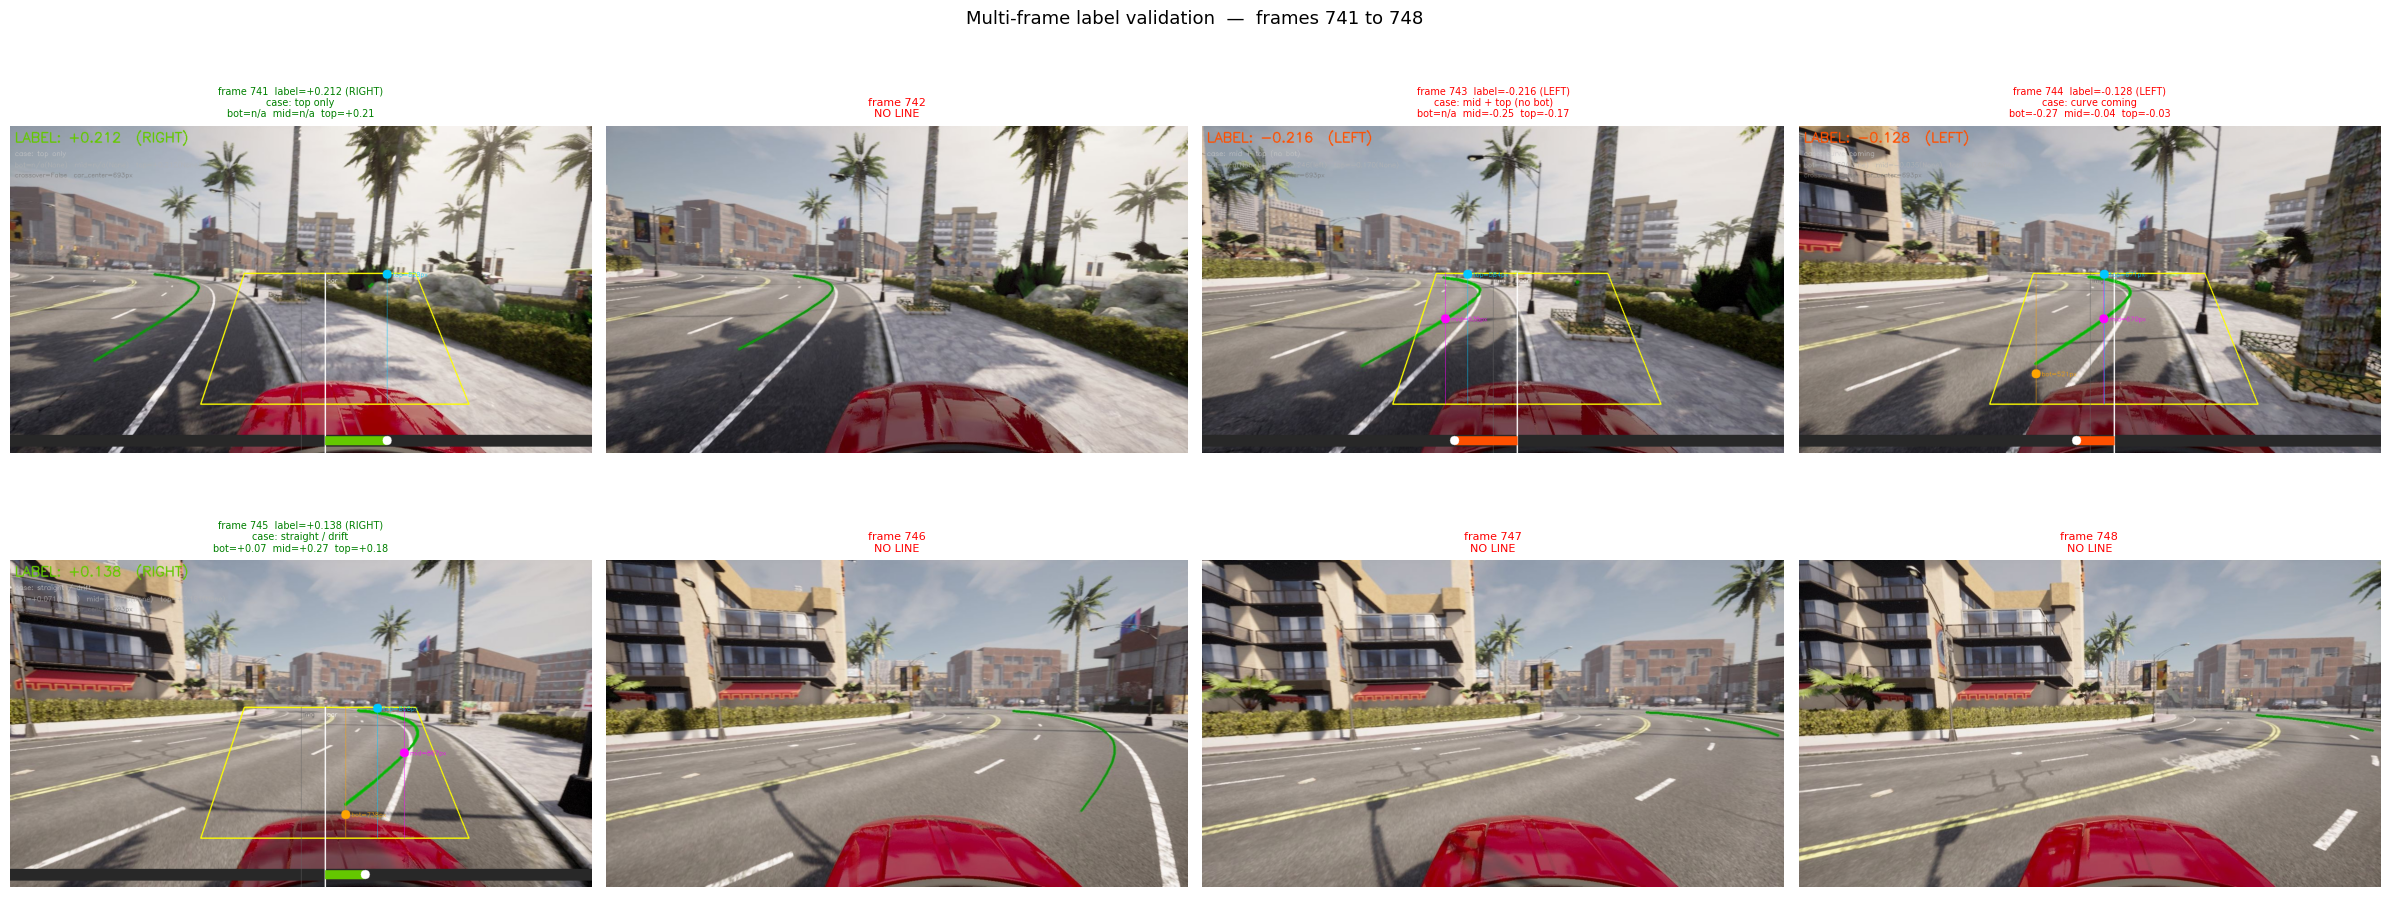

In [5]:
# ── Multi-frame label validation ─────────────────────────────────────────
# Shows FRAME_INDEX and the next N-1 frames side by side.
# Change FRAME_INDEX in the setup cell to move the window.

N_FRAMES = 8  # how many consecutive frames to show

results = []
for i in range(N_FRAMES):
    idx = FRAME_INDEX + i
    if idx >= len(image_paths):
        break
    fr = cv2.imread(str(image_paths[idx]))
    steer_i, info_i, vis_i = compute_label(fr, trap_pts, LOWER_GREEN, UPPER_GREEN, CAR_CENTER_X)
    results.append((idx, steer_i, info_i, vis_i))

cols = 4
rows = (len(results) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 5))
axes = np.array(axes).reshape(-1)  # flatten for easy indexing
fig.suptitle(f"Multi-frame label validation  —  frames {FRAME_INDEX} to {FRAME_INDEX + len(results) - 1}", fontsize=13)

for ax, (idx, steer_i, info_i, vis_i) in zip(axes, results):
    ax.imshow(cv2.cvtColor(vis_i, cv2.COLOR_BGR2RGB))
    if steer_i is None:
        ax.set_title(f"frame {idx}\nNO LINE", fontsize=8, color='red')
    else:
        direction = "LEFT" if steer_i < -0.05 else "RIGHT" if steer_i > 0.05 else "STRAIGHT"
        col       = 'red' if steer_i < -0.05 else 'green' if steer_i > 0.05 else 'gray'
        bot_s = f"{info_i['off_bot']:+.2f}" if info_i['has_bot'] else "n/a"
        mid_s = f"{info_i['off_mid']:+.2f}" if info_i['has_mid'] else "n/a"
        top_s = f"{info_i['off_top']:+.2f}" if info_i['has_top'] else "n/a"
        ax.set_title(
            f"frame {idx}  label={steer_i:+.3f} ({direction})\n"
            f"case: {info_i['case']}\n"
            f"bot={bot_s}  mid={mid_s}  top={top_s}",
            fontsize=7, color=col)
    ax.axis("off")

# hide unused axes
for ax in axes[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


Frame 741  |  case=top only  crossover=False
  bot=n/a(None)  mid=n/a(None)  top=+0.2125(None)
  LABEL=+0.2125  → RIGHT



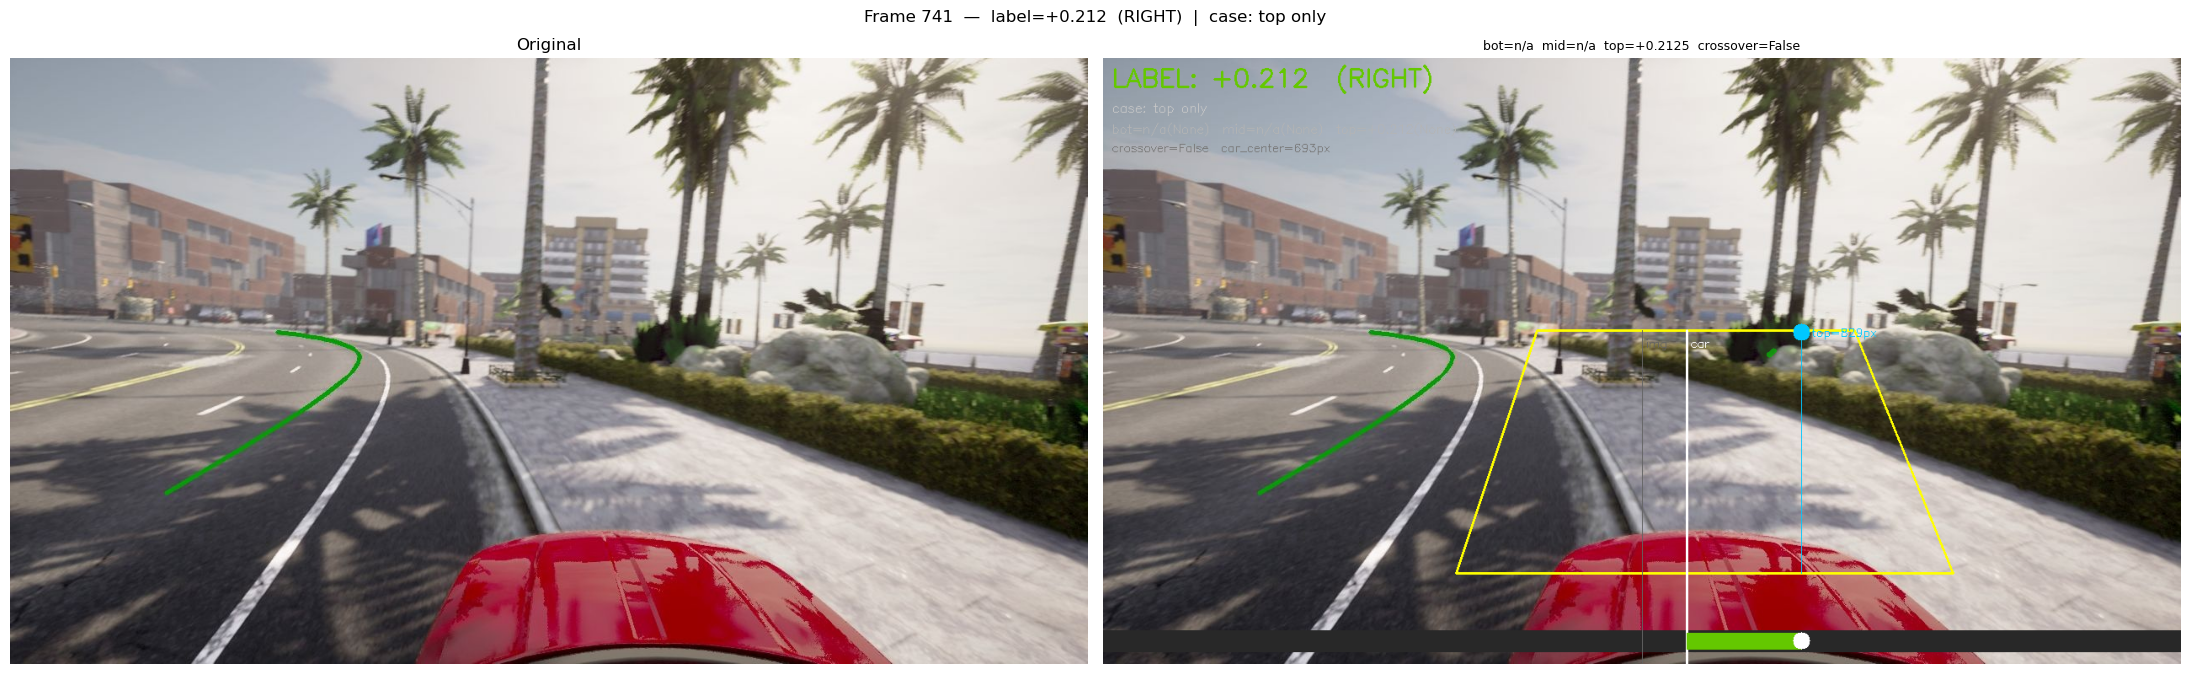

Frame 742: NO LINE DETECTED
Frame 743  |  case=mid + top (no bot)  crossover=False
  bot=n/a(None)  mid=-0.2459(left)  top=-0.1700(None)
  LABEL=-0.2155  → LEFT



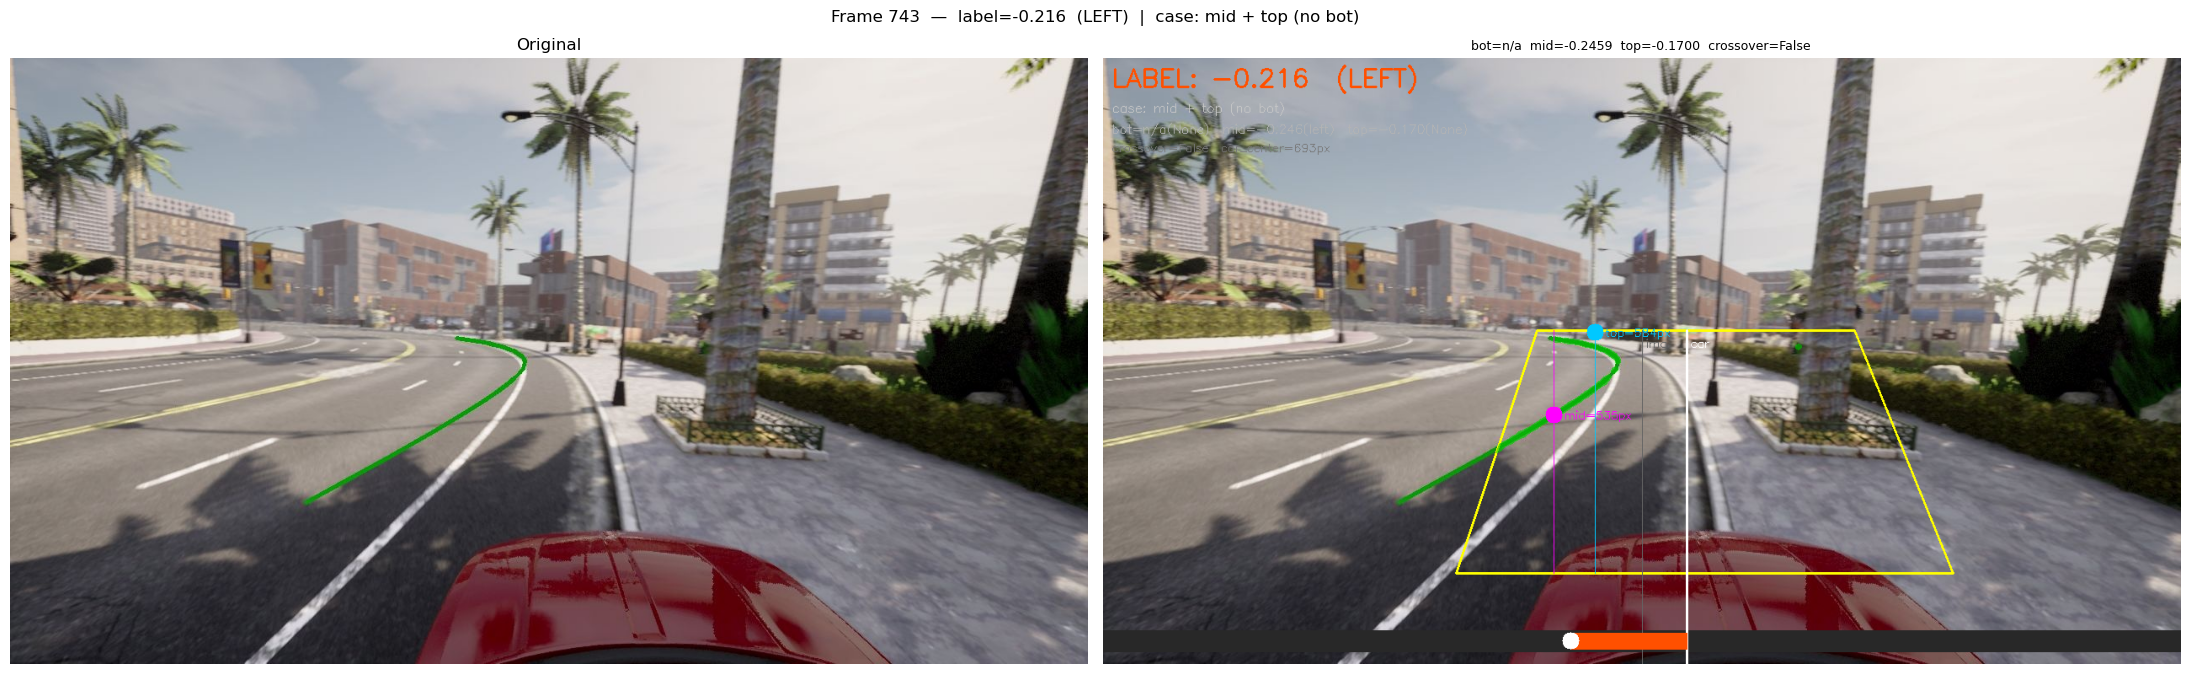

Frame 744  |  case=curve coming  crossover=False
  bot=-0.2687(None)  mid=-0.0353(None)  top=-0.0339(None)
  LABEL=-0.1283  → LEFT



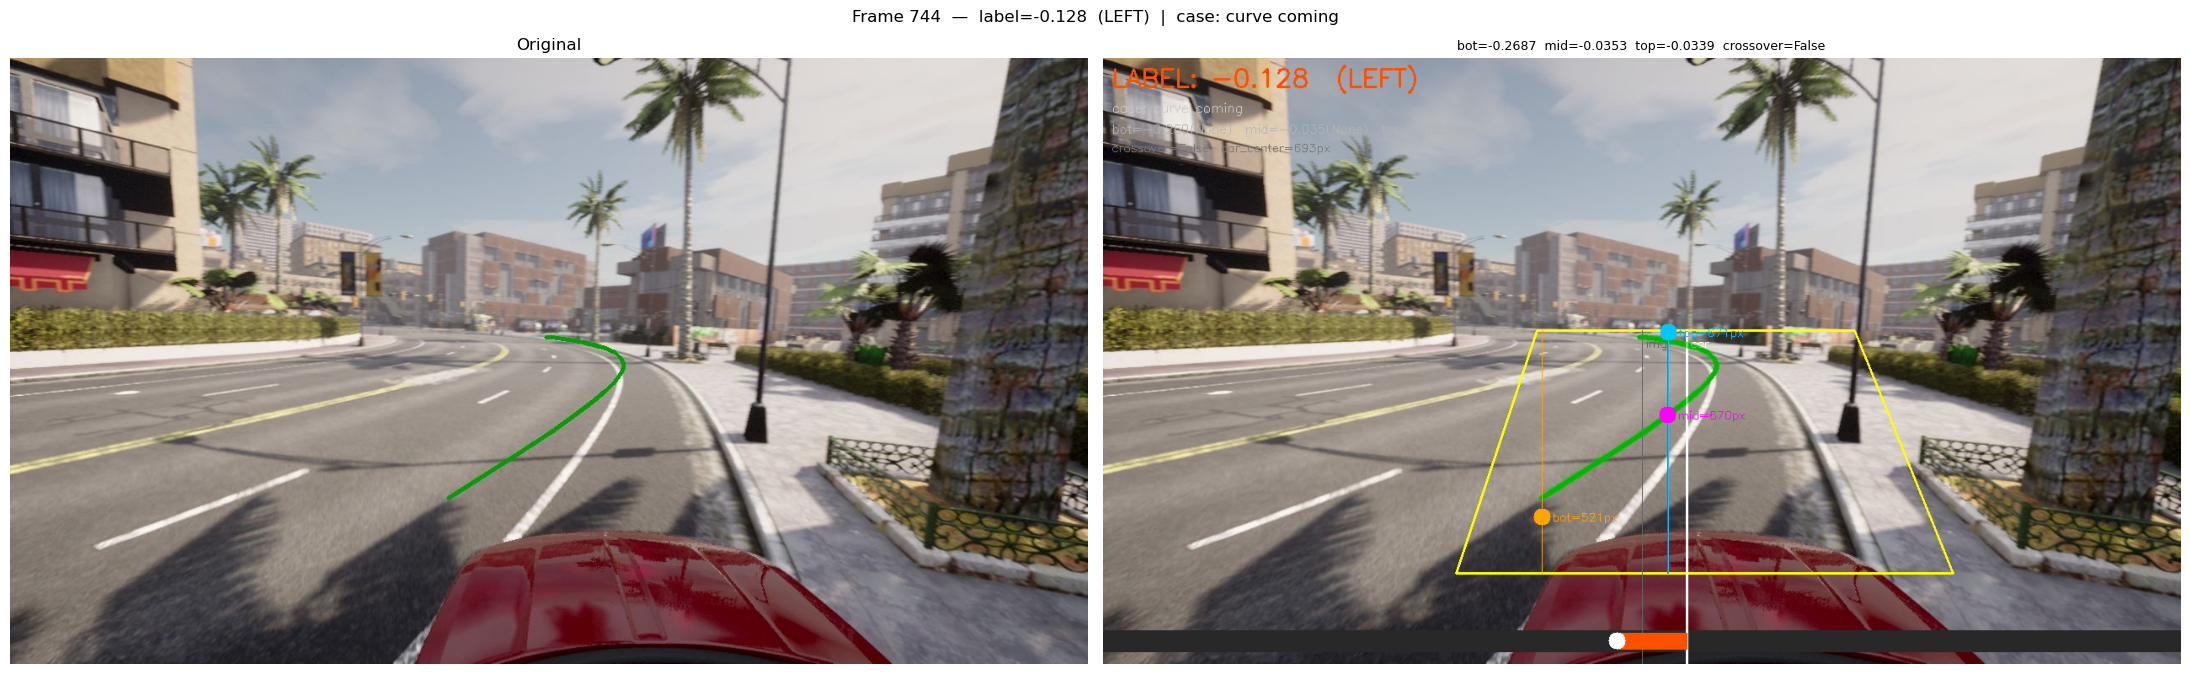

Frame 745  |  case=straight / drift  crossover=False
  bot=+0.0711(None)  mid=+0.2729(None)  top=+0.1809(None)
  LABEL=+0.1380  → RIGHT



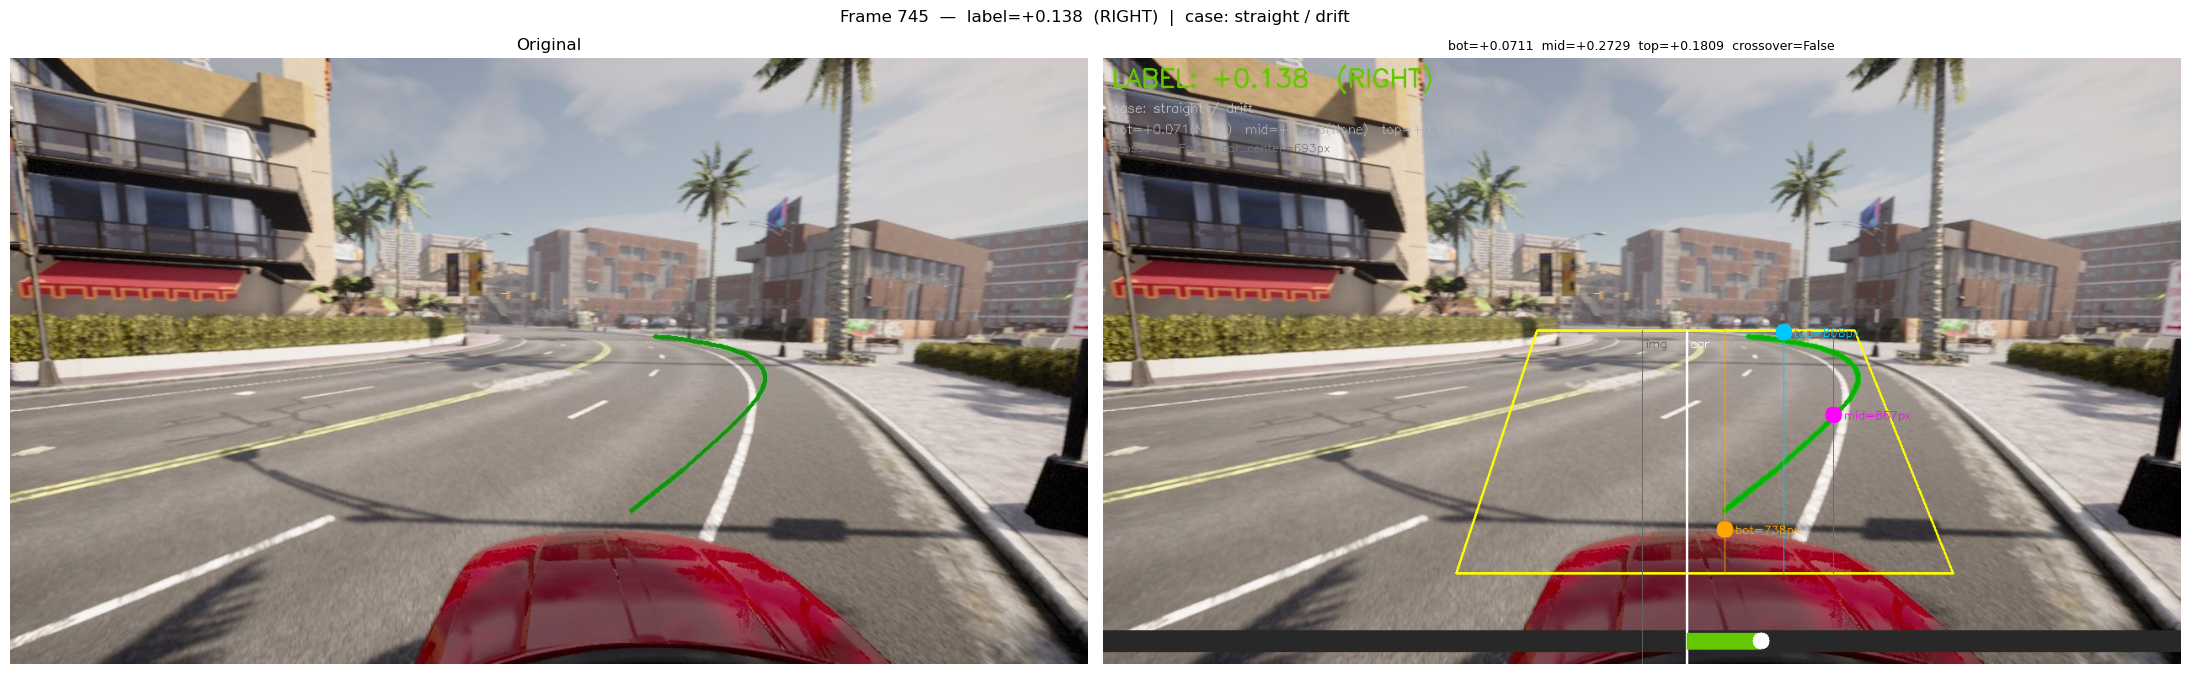

Frame 746: NO LINE DETECTED


In [6]:
# ── Individual large-frame inspection ────────────────────────────────────
# Shows 6 consecutive frames starting from FRAME_INDEX (set in setup cell).

N_INSPECT = 6

for idx in range(FRAME_INDEX, min(FRAME_INDEX + N_INSPECT, len(image_paths))):
    fr = cv2.imread(str(image_paths[idx]))
    steer_i, info_i, vis_i = compute_label(fr, trap_pts, LOWER_GREEN, UPPER_GREEN, CAR_CENTER_X)

    if steer_i is None:
        print(f"Frame {idx}: NO LINE DETECTED")
        continue

    bot_s = f"{info_i['off_bot']:+.4f}" if info_i['has_bot'] else "n/a"
    mid_s = f"{info_i['off_mid']:+.4f}" if info_i['has_mid'] else "n/a"
    top_s = f"{info_i['off_top']:+.4f}" if info_i['has_top'] else "n/a"
    print(f"Frame {idx}  |  case={info_i['case']}  crossover={info_i['crossover']}")
    print(f"  bot={bot_s}({info_i['bot_exit']})  mid={mid_s}({info_i['mid_exit']})  top={top_s}({info_i['top_exit']})")
    print(f"  LABEL={steer_i:+.4f}  → {'LEFT' if steer_i < -0.05 else 'RIGHT' if steer_i > 0.05 else 'STRAIGHT'}")
    print()

    direction = "LEFT" if steer_i < -0.05 else "RIGHT" if steer_i > 0.05 else "STRAIGHT"
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle(f"Frame {idx}  —  label={steer_i:+.3f}  ({direction})  |  case: {info_i['case']}", fontsize=12)
    axes[0].imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(vis_i, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"bot={bot_s}  mid={mid_s}  top={top_s}  crossover={info_i['crossover']}", fontsize=9)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
